# Phase 4 — Data Augmentation Experiments

This notebook investigates whether image augmentation improves the
generalization of the baseline CNN.

The following training configurations are compared:

1. No augmentation — reused from Phase 3
2. Horizontal flip
3. Random rotation
4. Random resized crop
5. Color jitter
6. Random affine transformation
7. Combined augmentation

All experiments use the same:

- Baseline CNN architecture
- Training and validation splits
- Class weights
- Batch size
- Optimizer
- Learning rate
- Weight decay
- Scheduler
- Maximum epoch count
- Early-stopping settings

The primary model-selection metric is validation macro F1.

In [2]:
import copy
import gc
import json
import random
import shutil
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch

from PIL import Image
from sklearn.utils.class_weight import compute_class_weight
from torch.utils.data import DataLoader
from torchvision import transforms


PROJECT_ROOT = Path.cwd().parent

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

print(f"Project root: {PROJECT_ROOT}")

Project root: /home/uteam6/computer-vision-equine-grimace-scale


In [3]:
from src.datasets.horse_dataset import HorseGrimaceDataset
from src.models.baseline_cnn import BaselineCNN
from src.training.losses import create_classification_loss
from src.training.trainer import Trainer
from src.transforms.image_transforms import (
    get_evaluation_transforms,
)

In [4]:
SEED = 42


def set_random_seed(seed: int = SEED) -> None:
    """
    Set random seeds for reproducible experiments.
    """
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False


set_random_seed()

device = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

print(f"Device: {device}")
print(f"Random seed: {SEED}")

if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")

Device: cuda
Random seed: 42
GPU: Quadro RTX 4000


In [5]:
TRAIN_CSV = (
    PROJECT_ROOT
    / "data"
    / "splits"
    / "train.csv"
)

VAL_CSV = (
    PROJECT_ROOT
    / "data"
    / "splits"
    / "validation.csv"
)

BASELINE_RESULTS_DIR = (
    PROJECT_ROOT
    / "results"
    / "baseline"
)

BASELINE_MODEL_PATH = (
    BASELINE_RESULTS_DIR
    / "best_model.pth"
)

BASELINE_HISTORY_PATH = (
    BASELINE_RESULTS_DIR
    / "training_history.csv"
)

RESULTS_DIR = (
    PROJECT_ROOT
    / "results"
    / "augmentation_experiments"
)

CHECKPOINTS_DIR = RESULTS_DIR / "checkpoints"
HISTORIES_DIR = RESULTS_DIR / "histories"
FIGURES_DIR = RESULTS_DIR / "figures"

for directory in [
    RESULTS_DIR,
    CHECKPOINTS_DIR,
    HISTORIES_DIR,
    FIGURES_DIR,
]:
    directory.mkdir(
        parents=True,
        exist_ok=True,
    )

print(f"Training CSV:          {TRAIN_CSV}")
print(f"Validation CSV:        {VAL_CSV}")
print(f"Baseline checkpoint:   {BASELINE_MODEL_PATH}")
print(f"Baseline history:      {BASELINE_HISTORY_PATH}")
print(f"Phase 4 results:       {RESULTS_DIR}")

assert TRAIN_CSV.exists(), f"Missing file: {TRAIN_CSV}"
assert VAL_CSV.exists(), f"Missing file: {VAL_CSV}"

assert BASELINE_MODEL_PATH.exists(), (
    f"Missing baseline checkpoint: {BASELINE_MODEL_PATH}"
)

assert BASELINE_HISTORY_PATH.exists(), (
    f"Missing baseline history: {BASELINE_HISTORY_PATH}"
)

Training CSV:          /home/uteam6/computer-vision-equine-grimace-scale/data/splits/train.csv
Validation CSV:        /home/uteam6/computer-vision-equine-grimace-scale/data/splits/validation.csv
Baseline checkpoint:   /home/uteam6/computer-vision-equine-grimace-scale/results/baseline/best_model.pth
Baseline history:      /home/uteam6/computer-vision-equine-grimace-scale/results/baseline/training_history.csv
Phase 4 results:       /home/uteam6/computer-vision-equine-grimace-scale/results/augmentation_experiments


In [6]:
IMAGE_SIZE = 224
NUM_CLASSES = 3

BATCH_SIZE = 32
NUM_WORKERS = 4

LEARNING_RATE = 1e-3
WEIGHT_DECAY = 1e-4
DROPOUT_RATE = 0.5

NUM_EPOCHS = 50
EARLY_STOPPING_PATIENCE = 10
EARLY_STOPPING_MIN_DELTA = 0.0

# Set this to True only when you intentionally want to retrain
# experiments whose checkpoint and history already exist.
OVERWRITE_EXISTING = False

CLASS_NAMES = [
    "Pain Score 0",
    "Pain Score 1",
    "Pain Score 2",
]

print(f"Image size:       {IMAGE_SIZE}")
print(f"Batch size:       {BATCH_SIZE}")
print(f"Maximum epochs:   {NUM_EPOCHS}")
print(f"Learning rate:    {LEARNING_RATE}")
print(f"Weight decay:     {WEIGHT_DECAY}")
print(f"Dropout rate:     {DROPOUT_RATE}")
print(f"Overwrite files:  {OVERWRITE_EXISTING}")

Image size:       224
Batch size:       32
Maximum epochs:   50
Learning rate:    0.001
Weight decay:     0.0001
Dropout rate:     0.5
Overwrite files:  False


In [7]:
train_df = pd.read_csv(TRAIN_CSV)
val_df = pd.read_csv(VAL_CSV)

print(f"Training samples:   {len(train_df)}")
print(f"Validation samples: {len(val_df)}")

print("\nTraining class distribution:")

display(
    train_df["pain_score"]
    .value_counts()
    .sort_index()
    .rename("count")
    .to_frame()
)

print("Validation class distribution:")

display(
    val_df["pain_score"]
    .value_counts()
    .sort_index()
    .rename("count")
    .to_frame()
)

Training samples:   2581
Validation samples: 315

Training class distribution:


,count
pain_score,
0,1607
1,555
2,419


Validation class distribution:


,count
pain_score,
0,203
1,67
2,45


In [8]:
train_labels = (
    train_df["pain_score"]
    .astype(int)
    .to_numpy()
)

class_indices = np.array(
    sorted(train_df["pain_score"].unique())
)

class_weights_array = compute_class_weight(
    class_weight="balanced",
    classes=class_indices,
    y=train_labels,
)

class_weights = torch.tensor(
    class_weights_array,
    dtype=torch.float32,
)

print("Class weights:")

for class_index, class_weight in zip(
    class_indices,
    class_weights_array,
):
    print(
        f"Class {class_index}: "
        f"{class_weight:.4f}"
    )

Class weights:
Class 0: 0.5354
Class 1: 1.5502
Class 2: 2.0533


In [9]:
evaluation_transform = get_evaluation_transforms(
    image_size=IMAGE_SIZE,
)

print("Validation transform:")
print(evaluation_transform)

Validation transform:
Compose(
    Resize(size=(224, 224), interpolation=bilinear, max_size=None, antialias=True)
    ToTensor()
    Normalize(mean=(0.485, 0.456, 0.406), std=(0.229, 0.224, 0.225))
)


In [10]:
augmentation_transforms = {
    "horizontal_flip": transforms.Compose(
        [
            transforms.RandomHorizontalFlip(
                p=0.5,
            ),
            evaluation_transform,
        ]
    ),

    "rotation": transforms.Compose(
        [
            transforms.RandomRotation(
                degrees=10,
                fill=0,
            ),
            evaluation_transform,
        ]
    ),

    "random_crop": transforms.Compose(
        [
            transforms.RandomResizedCrop(
                size=IMAGE_SIZE,
                scale=(0.85, 1.0),
                ratio=(0.90, 1.10),
            ),
            evaluation_transform,
        ]
    ),

    "color_jitter": transforms.Compose(
        [
            transforms.ColorJitter(
                brightness=0.20,
                contrast=0.20,
                saturation=0.15,
                hue=0.03,
            ),
            evaluation_transform,
        ]
    ),

    "affine": transforms.Compose(
        [
            transforms.RandomAffine(
                degrees=8,
                translate=(0.05, 0.05),
                scale=(0.95, 1.05),
                shear=4,
                fill=0,
            ),
            evaluation_transform,
        ]
    ),

    "combined": transforms.Compose(
        [
            transforms.RandomResizedCrop(
                size=IMAGE_SIZE,
                scale=(0.90, 1.0),
                ratio=(0.92, 1.08),
            ),
            transforms.RandomHorizontalFlip(
                p=0.5,
            ),
            transforms.RandomApply(
                [
                    transforms.RandomRotation(
                        degrees=8,
                        fill=0,
                    )
                ],
                p=0.5,
            ),
            transforms.RandomApply(
                [
                    transforms.ColorJitter(
                        brightness=0.15,
                        contrast=0.15,
                        saturation=0.10,
                        hue=0.02,
                    )
                ],
                p=0.5,
            ),
            transforms.RandomApply(
                [
                    transforms.RandomAffine(
                        degrees=0,
                        translate=(0.04, 0.04),
                        scale=(0.97, 1.03),
                        shear=3,
                        fill=0,
                    )
                ],
                p=0.4,
            ),
            evaluation_transform,
        ]
    ),
}

for experiment_name, experiment_transform in (
    augmentation_transforms.items()
):
    print(f"\n{experiment_name}:")
    print(experiment_transform)


horizontal_flip:
Compose(
    RandomHorizontalFlip(p=0.5)
    Compose(
    Resize(size=(224, 224), interpolation=bilinear, max_size=None, antialias=True)
    ToTensor()
    Normalize(mean=(0.485, 0.456, 0.406), std=(0.229, 0.224, 0.225))
)
)

rotation:
Compose(
    RandomRotation(degrees=[-10.0, 10.0], interpolation=nearest, expand=False, fill=0)
    Compose(
    Resize(size=(224, 224), interpolation=bilinear, max_size=None, antialias=True)
    ToTensor()
    Normalize(mean=(0.485, 0.456, 0.406), std=(0.229, 0.224, 0.225))
)
)

random_crop:
Compose(
    RandomResizedCrop(size=(224, 224), scale=(0.85, 1.0), ratio=(0.9, 1.1), interpolation=bilinear, antialias=True)
    Compose(
    Resize(size=(224, 224), interpolation=bilinear, max_size=None, antialias=True)
    ToTensor()
    Normalize(mean=(0.485, 0.456, 0.406), std=(0.229, 0.224, 0.225))
)
)

color_jitter:
Compose(
    ColorJitter(brightness=(0.8, 1.2), contrast=(0.8, 1.2), saturation=(0.85, 1.15), hue=(-0.03, 0.03))
    Compose(
  

In [11]:
def find_normalize_transform(transform_object):
    """
    Recursively search a torchvision transformation pipeline
    for a Normalize transformation.
    """
    if isinstance(
        transform_object,
        transforms.Normalize,
    ):
        return transform_object

    nested_transforms = getattr(
        transform_object,
        "transforms",
        [],
    )

    for nested_transform in nested_transforms:
        result = find_normalize_transform(
            nested_transform
        )

        if result is not None:
            return result

    return None


normalize_transform = find_normalize_transform(
    evaluation_transform
)

if normalize_transform is not None:
    normalization_mean = torch.tensor(
        normalize_transform.mean,
        dtype=torch.float32,
    ).view(3, 1, 1)

    normalization_std = torch.tensor(
        normalize_transform.std,
        dtype=torch.float32,
    ).view(3, 1, 1)

    print(
        "Normalization mean:",
        normalize_transform.mean,
    )

    print(
        "Normalization standard deviation:",
        normalize_transform.std,
    )
else:
    normalization_mean = None
    normalization_std = None

    print(
        "No Normalize transformation was found. "
        "Images will be displayed without denormalization."
    )

Normalization mean: (0.485, 0.456, 0.406)
Normalization standard deviation: (0.229, 0.224, 0.225)


In [12]:
def tensor_to_display_image(
    image_tensor: torch.Tensor,
) -> np.ndarray:
    """
    Convert a transformed image tensor into a displayable
    NumPy image.
    """
    image_tensor = (
        image_tensor
        .detach()
        .cpu()
        .clone()
    )

    if (
        normalization_mean is not None
        and normalization_std is not None
    ):
        image_tensor = (
            image_tensor * normalization_std
            + normalization_mean
        )

    image_tensor = image_tensor.clamp(
        0.0,
        1.0,
    )

    image_array = (
        image_tensor
        .permute(1, 2, 0)
        .numpy()
    )

    return image_array

In [13]:
def resolve_image_path(
    stored_path: str,
) -> Path:
    """
    Resolve a path stored in the split CSV.
    """
    image_path = Path(
        str(stored_path)
    )

    if image_path.is_absolute():
        return image_path

    return PROJECT_ROOT / image_path

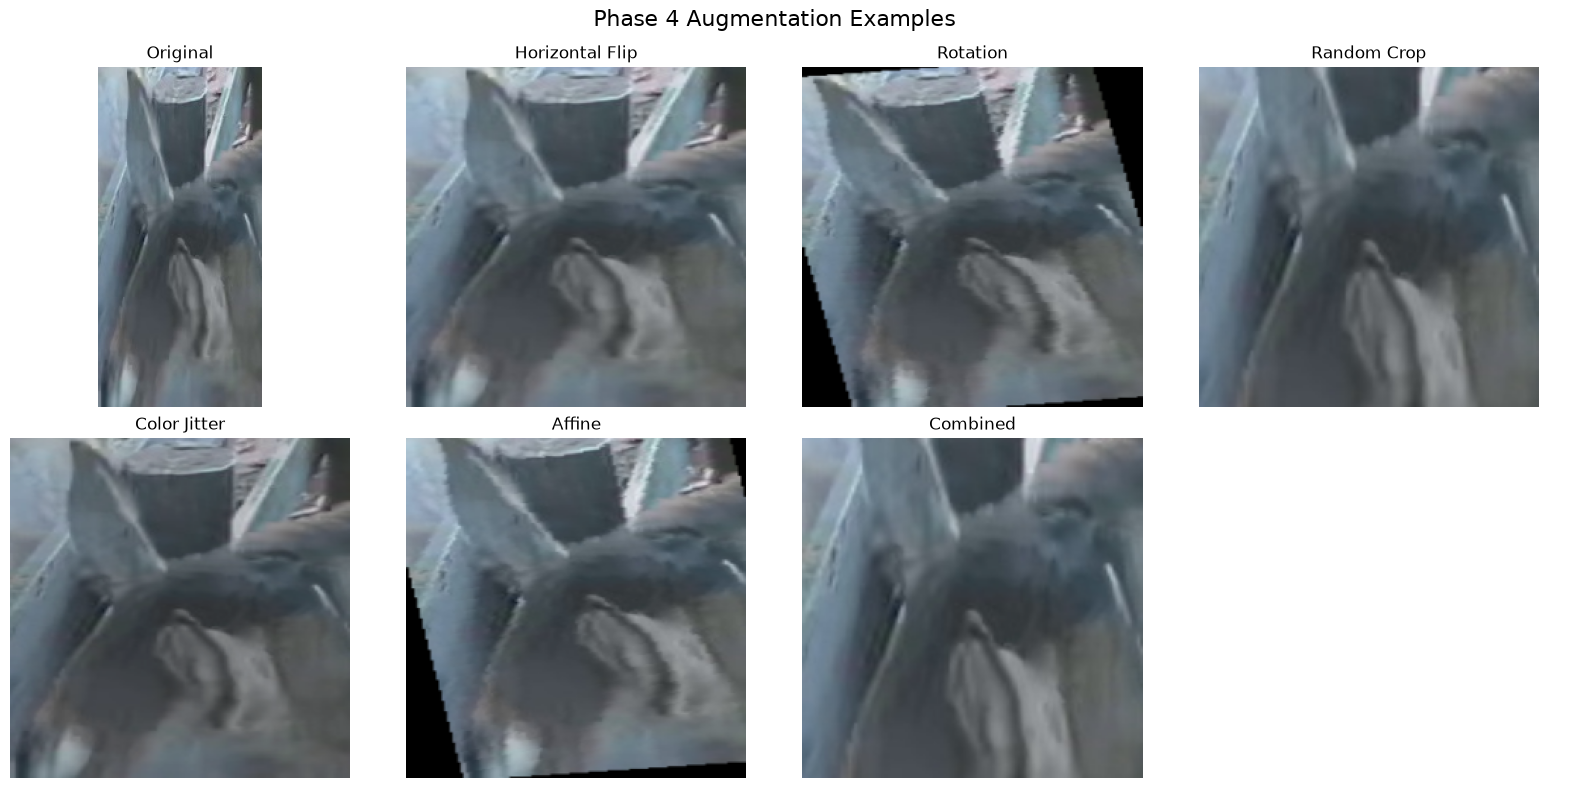

Augmentation samples saved to: /home/uteam6/computer-vision-equine-grimace-scale/results/augmentation_experiments/figures/augmentation_samples.png


In [14]:
example_row = train_df.iloc[0]

example_image_path = resolve_image_path(
    example_row["image_path"]
)

assert example_image_path.exists(), (
    f"Image was not found: {example_image_path}"
)

example_image = Image.open(
    example_image_path
).convert("RGB")

set_random_seed(SEED)

figure, axes = plt.subplots(
    2,
    4,
    figsize=(16, 8),
)

axes = axes.flatten()

axes[0].imshow(example_image)
axes[0].set_title("Original")
axes[0].axis("off")

for axis, (
    experiment_name,
    experiment_transform,
) in zip(
    axes[1:],
    augmentation_transforms.items(),
):
    transformed_image = experiment_transform(
        example_image
    )

    axis.imshow(
        tensor_to_display_image(
            transformed_image
        )
    )

    axis.set_title(
        experiment_name.replace(
            "_",
            " ",
        ).title()
    )

    axis.axis("off")

for axis in axes[
    len(augmentation_transforms) + 1:
]:
    axis.axis("off")

plt.suptitle(
    "Phase 4 Augmentation Examples",
    fontsize=16,
)

plt.tight_layout()

augmentation_samples_path = (
    FIGURES_DIR
    / "augmentation_samples.png"
)

plt.savefig(
    augmentation_samples_path,
    dpi=300,
    bbox_inches="tight",
)

plt.show()

print(
    f"Augmentation samples saved to: "
    f"{augmentation_samples_path}"
)

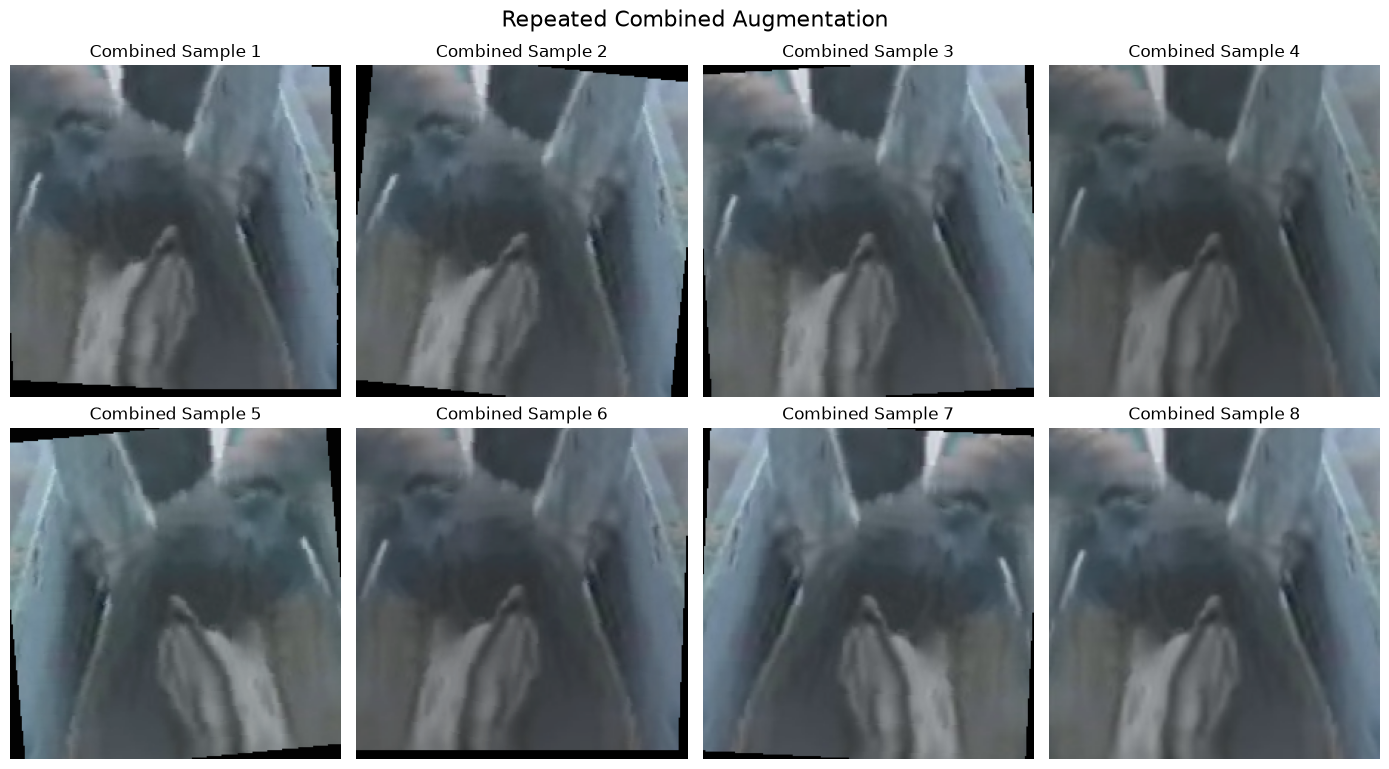

In [15]:
set_random_seed(SEED)

figure, axes = plt.subplots(
    2,
    4,
    figsize=(14, 8),
)

axes = axes.flatten()

combined_transform = augmentation_transforms[
    "combined"
]

for sample_index, axis in enumerate(
    axes,
    start=1,
):
    transformed_image = combined_transform(
        example_image
    )

    axis.imshow(
        tensor_to_display_image(
            transformed_image
        )
    )

    axis.set_title(
        f"Combined Sample {sample_index}"
    )

    axis.axis("off")

plt.suptitle(
    "Repeated Combined Augmentation",
    fontsize=16,
)

plt.tight_layout()

combined_samples_path = (
    FIGURES_DIR
    / "combined_augmentation_samples.png"
)

plt.savefig(
    combined_samples_path,
    dpi=300,
    bbox_inches="tight",
)

plt.show()

In [16]:
def seed_worker(
    worker_id: int,
) -> None:
    """
    Give each DataLoader worker a reproducible random seed.
    """
    worker_seed = (
        torch.initial_seed()
        % (2 ** 32)
    )

    np.random.seed(worker_seed)
    random.seed(worker_seed)

In [17]:
def create_train_loader(
    train_transform,
    seed: int = SEED,
) -> DataLoader:
    """
    Create a training DataLoader for one augmentation
    configuration.
    """
    train_dataset = HorseGrimaceDataset(
        csv_file=TRAIN_CSV,
        image_root=PROJECT_ROOT,
        transform=train_transform,
        verify_images=True,
    )

    loader_generator = torch.Generator()
    loader_generator.manual_seed(seed)

    train_loader = DataLoader(
        train_dataset,
        batch_size=BATCH_SIZE,
        shuffle=True,
        num_workers=NUM_WORKERS,
        pin_memory=torch.cuda.is_available(),
        persistent_workers=NUM_WORKERS > 0,
        worker_init_fn=seed_worker,
        generator=loader_generator,
    )

    return train_loader


def create_validation_loader() -> DataLoader:
    """
    Create the deterministic validation DataLoader.
    """
    validation_dataset = HorseGrimaceDataset(
        csv_file=VAL_CSV,
        image_root=PROJECT_ROOT,
        transform=evaluation_transform,
        verify_images=True,
    )

    validation_loader = DataLoader(
        validation_dataset,
        batch_size=BATCH_SIZE,
        shuffle=False,
        num_workers=NUM_WORKERS,
        pin_memory=torch.cuda.is_available(),
        persistent_workers=NUM_WORKERS > 0,
        worker_init_fn=seed_worker,
    )

    return validation_loader


val_loader = create_validation_loader()

print(
    f"Validation batches: {len(val_loader)}"
)

Validation batches: 10


In [18]:
example_train_loader = create_train_loader(
    augmentation_transforms[
        "horizontal_flip"
    ]
)

example_batch = next(
    iter(example_train_loader)
)

print(
    f"Image batch shape: "
    f"{example_batch['image'].shape}"
)

print(
    f"Pain-score shape: "
    f"{example_batch['pain_score'].shape}"
)

print(
    "Unique pain scores:",
    example_batch["pain_score"].unique(
        sorted=True
    ),
)

del example_train_loader
del example_batch

gc.collect()

if torch.cuda.is_available():
    torch.cuda.empty_cache()

Image batch shape: torch.Size([32, 3, 224, 224])
Pain-score shape: torch.Size([32])
Unique pain scores: tensor([0, 1, 2])


In [19]:
def convert_metric_value(
    metric_value,
):
    """
    Convert tensors, NumPy values and Python values into
    serializable Python objects.
    """
    if isinstance(
        metric_value,
        torch.Tensor,
    ):
        if metric_value.numel() == 1:
            return float(
                metric_value.item()
            )

        return [
            float(value)
            for value in metric_value
            .detach()
            .cpu()
            .flatten()
            .tolist()
        ]

    if isinstance(
        metric_value,
        np.ndarray,
    ):
        if metric_value.size == 1:
            return float(
                metric_value.item()
            )

        return [
            float(value)
            for value in metric_value.flatten()
        ]

    if isinstance(
        metric_value,
        (np.floating, np.integer),
    ):
        return metric_value.item()

    if isinstance(
        metric_value,
        list,
    ):
        return [
            convert_metric_value(value)
            for value in metric_value
        ]

    return metric_value

In [20]:
def create_experiment_components(
    checkpoint_path: Path,
):
    """
    Create a fresh model, loss, optimizer, scheduler and
    Trainer for one controlled experiment.
    """
    model = BaselineCNN(
        num_classes=NUM_CLASSES,
        dropout_rate=DROPOUT_RATE,
    ).to(device)

    criterion = create_classification_loss(
        class_weights=class_weights,
        device=device,
    )

    optimizer = torch.optim.Adam(
        model.parameters(),
        lr=LEARNING_RATE,
        weight_decay=WEIGHT_DECAY,
    )

    scheduler = (
        torch.optim.lr_scheduler
        .ReduceLROnPlateau(
            optimizer,
            mode="min",
            factor=0.5,
            patience=3,
            min_lr=1e-6,
        )
    )

    trainer = Trainer(
        model=model,
        criterion=criterion,
        optimizer=optimizer,
        device=device,
        num_classes=NUM_CLASSES,
        scheduler=scheduler,
        checkpoint_path=checkpoint_path,
        early_stopping_patience=(
            EARLY_STOPPING_PATIENCE
        ),
        early_stopping_min_delta=(
            EARLY_STOPPING_MIN_DELTA
        ),
    )

    return {
        "model": model,
        "criterion": criterion,
        "optimizer": optimizer,
        "scheduler": scheduler,
        "trainer": trainer,
    }

In [21]:
def find_checkpoint_history_row(
    history_df: pd.DataFrame,
    checkpoint: dict,
) -> pd.Series:
    """
    Find the history row corresponding most closely to the
    checkpoint's saved validation loss.

    This avoids assuming whether the Trainer stores epochs using
    zero-based or one-based numbering.
    """
    checkpoint_val_loss = float(
        checkpoint["validation_loss"]
    )

    loss_difference = (
        history_df["val_loss"]
        .astype(float)
        .sub(checkpoint_val_loss)
        .abs()
    )

    matching_index = loss_difference.idxmin()

    return history_df.loc[
        matching_index
    ]

In [26]:
def get_history_value(
    history_row: pd.Series,
    possible_column_names: list[str],
    required: bool = True,
):
    """
    Return the value from the first matching history column.

    This supports slightly different metric names produced by
    different Trainer versions.
    """
    for column_name in possible_column_names:
        if column_name in history_row.index:
            return float(
                history_row[column_name]
            )

    if required:
        raise KeyError(
            "None of the expected history columns were found. "
            f"Expected one of: {possible_column_names}. "
            f"Available columns: {history_row.index.tolist()}"
        )

    return None


def evaluate_checkpoint(
    checkpoint_path: Path,
    history_path: Path,
    experiment_name: str,
) -> dict:
    """
    Load one saved checkpoint, evaluate it on validation data,
    and return a summary dictionary.
    """
    components = create_experiment_components(
        checkpoint_path=checkpoint_path,
    )

    model = components["model"]
    trainer = components["trainer"]

    checkpoint = torch.load(
        checkpoint_path,
        map_location=device,
        weights_only=False,
    )

    model.load_state_dict(
        checkpoint["model_state_dict"]
    )

    model.eval()

    validation_results = trainer.predict(
        val_loader
    )

    validation_metrics = {
        metric_name: convert_metric_value(
            metric_value
        )
        for metric_name, metric_value
        in validation_results["metrics"].items()
    }

    history_df = pd.read_csv(
        history_path
    )

    checkpoint_history_row = (
        find_checkpoint_history_row(
            history_df=history_df,
            checkpoint=checkpoint,
        )
    )

    validation_macro_f1 = float(
        validation_metrics["macro_f1"]
    )

    validation_accuracy = float(
        validation_metrics["accuracy"]
    )

    checkpoint_validation_loss = float(
        checkpoint["validation_loss"]
    )

    train_accuracy_at_checkpoint = (
        get_history_value(
            history_row=checkpoint_history_row,
            possible_column_names=[
                "train_accuracy",
                "training_accuracy",
            ],
        )
    )

    validation_accuracy_at_checkpoint = (
        get_history_value(
            history_row=checkpoint_history_row,
            possible_column_names=[
                "val_accuracy",
                "validation_accuracy",
            ],
        )
    )

    train_macro_f1_at_checkpoint = (
        get_history_value(
            history_row=checkpoint_history_row,
            possible_column_names=[
                "train_macro_f1",
                "train_f1",
                "training_macro_f1",
                "training_f1",
            ],
            required=False,
        )
    )

    validation_macro_f1_at_checkpoint = (
        get_history_value(
            history_row=checkpoint_history_row,
            possible_column_names=[
                "val_macro_f1",
                "val_f1",
                "validation_macro_f1",
                "validation_f1",
            ],
        )
    )

    accuracy_overfitting_gap = (
        train_accuracy_at_checkpoint
        - validation_accuracy
    )

    if train_macro_f1_at_checkpoint is not None:
        macro_f1_overfitting_gap = (
            train_macro_f1_at_checkpoint
            - validation_macro_f1
        )
    else:
        macro_f1_overfitting_gap = np.nan

    summary = {
        "experiment": experiment_name,
        "checkpoint_epoch": int(
            checkpoint["epoch"]
        ),
        "epochs_completed": int(
            len(history_df)
        ),
        "validation_loss": (
            checkpoint_validation_loss
        ),
        "validation_accuracy": (
            validation_accuracy
        ),
        "validation_macro_f1": (
            validation_macro_f1
        ),
        "train_accuracy_at_checkpoint": (
            train_accuracy_at_checkpoint
        ),
        "history_val_accuracy_at_checkpoint": (
            validation_accuracy_at_checkpoint
        ),
        "train_macro_f1_at_checkpoint": (
            train_macro_f1_at_checkpoint
        ),
        "history_val_macro_f1_at_checkpoint": (
            validation_macro_f1_at_checkpoint
        ),
        "macro_f1_overfitting_gap": (
            macro_f1_overfitting_gap
        ),
        "accuracy_overfitting_gap": (
            accuracy_overfitting_gap
        ),
        "best_history_val_macro_f1": float(
            history_df[
                "val_macro_f1"
            ].max()
        ),
        "best_history_val_accuracy": float(
            history_df[
                "val_accuracy"
            ].max()
        ),
        "lowest_history_val_loss": float(
            history_df[
                "val_loss"
            ].min()
        ),
        "checkpoint_path": str(
            checkpoint_path
        ),
        "history_path": str(
            history_path
        ),
    }

    for metric_name, metric_value in (
        validation_metrics.items()
    ):
        summary[
            f"validation_metric_{metric_name}"
        ] = metric_value

    del components
    del model
    del trainer
    del checkpoint
    del validation_results

    gc.collect()

    if torch.cuda.is_available():
        torch.cuda.empty_cache()

    return summary

In [27]:
def run_augmentation_experiment(
    experiment_name: str,
    train_transform,
    overwrite: bool = OVERWRITE_EXISTING,
) -> dict:
    """
    Train and evaluate one augmentation configuration.
    """
    print("=" * 80)
    print(
        f"Experiment: {experiment_name}"
    )
    print("=" * 80)

    set_random_seed(SEED)

    checkpoint_path = (
        CHECKPOINTS_DIR
        / f"{experiment_name}_best.pth"
    )

    history_path = (
        HISTORIES_DIR
        / f"{experiment_name}_history.csv"
    )

    metrics_path = (
        RESULTS_DIR
        / f"{experiment_name}_validation_metrics.json"
    )

    files_already_exist = (
        checkpoint_path.exists()
        and history_path.exists()
    )

    if files_already_exist and not overwrite:
        print(
            "Existing checkpoint and history found. "
            "Training will be skipped."
        )
    else:
        train_loader = create_train_loader(
            train_transform=train_transform,
            seed=SEED,
        )

        components = create_experiment_components(
            checkpoint_path=checkpoint_path,
        )

        trainer = components["trainer"]

        print(
            f"Training batches: {len(train_loader)}"
        )

        history = trainer.fit(
            train_loader=train_loader,
            val_loader=val_loader,
            num_epochs=NUM_EPOCHS,
        )

        history_df = pd.DataFrame(
            history
        )

        history_df.to_csv(
            history_path,
            index=False,
        )

        print(
            f"History saved to: {history_path}"
        )

        del train_loader
        del components
        del trainer
        del history
        del history_df

        gc.collect()

        if torch.cuda.is_available():
            torch.cuda.empty_cache()

    assert checkpoint_path.exists(), (
        f"Checkpoint was not created: "
        f"{checkpoint_path}"
    )

    assert history_path.exists(), (
        f"History was not created: "
        f"{history_path}"
    )

    experiment_summary = evaluate_checkpoint(
        checkpoint_path=checkpoint_path,
        history_path=history_path,
        experiment_name=experiment_name,
    )

    serializable_summary = {
        key: convert_metric_value(value)
        for key, value
        in experiment_summary.items()
    }

    with open(
        metrics_path,
        "w",
        encoding="utf-8",
    ) as output_file:
        json.dump(
            serializable_summary,
            output_file,
            indent=4,
        )

    print("\nValidation summary:")

    print(
        "Validation loss:"
        f" {experiment_summary['validation_loss']:.4f}"
    )

    print(
        "Validation accuracy:"
        f" {experiment_summary['validation_accuracy']:.4f}"
    )

    print(
        "Validation macro F1:"
        f" {experiment_summary['validation_macro_f1']:.4f}"
    )

    print(
        "Macro-F1 overfitting gap:"
        f" {experiment_summary['macro_f1_overfitting_gap']:.4f}"
    )

    print(
        f"Checkpoint: {checkpoint_path}"
    )

    return experiment_summary

In [29]:
baseline_summary = evaluate_checkpoint(
    checkpoint_path=BASELINE_MODEL_PATH,
    history_path=BASELINE_HISTORY_PATH,
    experiment_name="no_augmentation",
)

print("Phase 3 baseline validation summary:")

print(
    "Validation loss:"
    f" {baseline_summary['validation_loss']:.4f}"
)

print(
    "Validation accuracy:"
    f" {baseline_summary['validation_accuracy']:.4f}"
)

print(
    "Validation macro F1:"
    f" {baseline_summary['validation_macro_f1']:.4f}"
)

print(
    "Macro-F1 overfitting gap:"
    f" {baseline_summary['macro_f1_overfitting_gap']:.4f}"
)

Evaluation:   0%|          | 0/10 [00:00<?, ?it/s]

Phase 3 baseline validation summary:
Validation loss: 0.7448
Validation accuracy: 0.7111
Validation macro F1: 0.5675
Macro-F1 overfitting gap: nan


In [30]:
horizontal_flip_summary = (
    run_augmentation_experiment(
        experiment_name="horizontal_flip",
        train_transform=augmentation_transforms[
            "horizontal_flip"
        ],
    )
)

Experiment: horizontal_flip
Training batches: 81


Training:   0%|          | 0/81 [00:00<?, ?it/s]

Validation:   0%|          | 0/10 [00:00<?, ?it/s]

Epoch 001/050 | Train Loss: 1.0032 | Train Acc: 0.5386 | Val Loss: 0.8437 | Val Acc: 0.6286 | Macro F1: 0.4194 | LR: 1.00e-03
Saved new best checkpoint.


Training:   0%|          | 0/81 [00:00<?, ?it/s]

...

Training:   0%|          | 0/81 [00:00<?, ?it/s]

Validation:   0%|          | 0/10 [00:00<?, ?it/s]

Epoch 042/050 | Train Loss: 0.8289 | Train Acc: 0.6749 | Val Loss: 0.7596 | Val Acc: 0.6730 | Macro F1: 0.5278 | LR: 1.56e-05
Early stopping triggered at epoch 42.
History saved to: /home/uteam6/computer-vision-equine-grimace-scale/results/augmentation_experiments/histories/horizontal_flip_history.csv


Evaluation:   0%|          | 0/10 [00:00<?, ?it/s]


Validation summary:
Validation loss: 0.7412
Validation accuracy: 0.6921
Validation macro F1: 0.5282
Macro-F1 overfitting gap: nan
Checkpoint: /home/uteam6/computer-vision-equine-grimace-scale/results/augmentation_experiments/checkpoints/horizontal_flip_best.pth


In [31]:
rotation_summary = (
    run_augmentation_experiment(
        experiment_name="rotation",
        train_transform=augmentation_transforms[
            "rotation"
        ],
    )
)

Experiment: rotation
Training batches: 81


Training:   0%|          | 0/81 [00:00<?, ?it/s]

Validation:   0%|          | 0/10 [00:00<?, ?it/s]

Epoch 001/050 | Train Loss: 1.0027 | Train Acc: 0.5440 | Val Loss: 0.8477 | Val Acc: 0.6063 | Macro F1: 0.3899 | LR: 1.00e-03
Saved new best checkpoint.


Training:   0%|          | 0/81 [00:00<?, ?it/s]

...

Training:   0%|          | 0/81 [00:00<?, ?it/s]

Validation:   0%|          | 0/10 [00:00<?, ?it/s]

Epoch 031/050 | Train Loss: 0.8240 | Train Acc: 0.6807 | Val Loss: 0.7828 | Val Acc: 0.6825 | Macro F1: 0.5330 | LR: 6.25e-05
Early stopping triggered at epoch 31.
History saved to: /home/uteam6/computer-vision-equine-grimace-scale/results/augmentation_experiments/histories/rotation_history.csv


Evaluation:   0%|          | 0/10 [00:00<?, ?it/s]


Validation summary:
Validation loss: 0.7681
Validation accuracy: 0.6762
Validation macro F1: 0.5121
Macro-F1 overfitting gap: nan
Checkpoint: /home/uteam6/computer-vision-equine-grimace-scale/results/augmentation_experiments/checkpoints/rotation_best.pth


In [32]:
random_crop_summary = (
    run_augmentation_experiment(
        experiment_name="random_crop",
        train_transform=augmentation_transforms[
            "random_crop"
        ],
    )
)

Experiment: random_crop
Training batches: 81


Training:   0%|          | 0/81 [00:00<?, ?it/s]

Validation:   0%|          | 0/10 [00:00<?, ?it/s]

Epoch 001/050 | Train Loss: 1.0116 | Train Acc: 0.5300 | Val Loss: 0.8306 | Val Acc: 0.6444 | Macro F1: 0.4240 | LR: 1.00e-03
Saved new best checkpoint.


Training:   0%|          | 0/81 [00:00<?, ?it/s]

...

Training:   0%|          | 0/81 [00:00<?, ?it/s]

Validation:   0%|          | 0/10 [00:00<?, ?it/s]

Epoch 041/050 | Train Loss: 0.7994 | Train Acc: 0.6846 | Val Loss: 0.7660 | Val Acc: 0.6952 | Macro F1: 0.5459 | LR: 1.56e-05
Early stopping triggered at epoch 41.
History saved to: /home/uteam6/computer-vision-equine-grimace-scale/results/augmentation_experiments/histories/random_crop_history.csv


Evaluation:   0%|          | 0/10 [00:00<?, ?it/s]


Validation summary:
Validation loss: 0.7395
Validation accuracy: 0.7048
Validation macro F1: 0.5695
Macro-F1 overfitting gap: nan
Checkpoint: /home/uteam6/computer-vision-equine-grimace-scale/results/augmentation_experiments/checkpoints/random_crop_best.pth


In [33]:
color_jitter_summary = (
    run_augmentation_experiment(
        experiment_name="color_jitter",
        train_transform=augmentation_transforms[
            "color_jitter"
        ],
    )
)

Experiment: color_jitter
Training batches: 81


Training:   0%|          | 0/81 [00:00<?, ?it/s]

Validation:   0%|          | 0/10 [00:00<?, ?it/s]

Epoch 001/050 | Train Loss: 1.0143 | Train Acc: 0.5269 | Val Loss: 0.9086 | Val Acc: 0.5746 | Macro F1: 0.4000 | LR: 1.00e-03
Saved new best checkpoint.


Training:   0%|          | 0/81 [00:00<?, ?it/s]

...

Training:   0%|          | 0/81 [00:00<?, ?it/s]

Validation:   0%|          | 0/10 [00:00<?, ?it/s]

Epoch 031/050 | Train Loss: 0.8552 | Train Acc: 0.6494 | Val Loss: 0.8076 | Val Acc: 0.6857 | Macro F1: 0.5393 | LR: 6.25e-05
Early stopping triggered at epoch 31.
History saved to: /home/uteam6/computer-vision-equine-grimace-scale/results/augmentation_experiments/histories/color_jitter_history.csv


Evaluation:   0%|          | 0/10 [00:00<?, ?it/s]


Validation summary:
Validation loss: 0.7682
Validation accuracy: 0.6825
Validation macro F1: 0.5268
Macro-F1 overfitting gap: nan
Checkpoint: /home/uteam6/computer-vision-equine-grimace-scale/results/augmentation_experiments/checkpoints/color_jitter_best.pth


In [34]:
affine_summary = (
    run_augmentation_experiment(
        experiment_name="affine",
        train_transform=augmentation_transforms[
            "affine"
        ],
    )
)

Experiment: affine
Training batches: 81


Training:   0%|          | 0/81 [00:00<?, ?it/s]

Validation:   0%|          | 0/10 [00:00<?, ?it/s]

Epoch 001/050 | Train Loss: 1.0042 | Train Acc: 0.5370 | Val Loss: 0.8997 | Val Acc: 0.5524 | Macro F1: 0.3698 | LR: 1.00e-03
Saved new best checkpoint.


Training:   0%|          | 0/81 [00:00<?, ?it/s]

...

Training:   0%|          | 0/81 [00:00<?, ?it/s]

Validation:   0%|          | 0/10 [00:00<?, ?it/s]

Epoch 031/050 | Train Loss: 0.8446 | Train Acc: 0.6672 | Val Loss: 0.7788 | Val Acc: 0.6921 | Macro F1: 0.5455 | LR: 3.13e-05
Early stopping triggered at epoch 31.
History saved to: /home/uteam6/computer-vision-equine-grimace-scale/results/augmentation_experiments/histories/affine_history.csv


Evaluation:   0%|          | 0/10 [00:00<?, ?it/s]


Validation summary:
Validation loss: 0.7532
Validation accuracy: 0.6857
Validation macro F1: 0.5220
Macro-F1 overfitting gap: nan
Checkpoint: /home/uteam6/computer-vision-equine-grimace-scale/results/augmentation_experiments/checkpoints/affine_best.pth


In [35]:
combined_summary = (
    run_augmentation_experiment(
        experiment_name="combined",
        train_transform=augmentation_transforms[
            "combined"
        ],
    )
)

Experiment: combined
Training batches: 81


Training:   0%|          | 0/81 [00:00<?, ?it/s]

Validation:   0%|          | 0/10 [00:00<?, ?it/s]

Epoch 001/050 | Train Loss: 1.0207 | Train Acc: 0.5277 | Val Loss: 0.9043 | Val Acc: 0.5810 | Macro F1: 0.3842 | LR: 1.00e-03
Saved new best checkpoint.


Training:   0%|          | 0/81 [00:00<?, ?it/s]

...

Training:   0%|          | 0/81 [00:00<?, ?it/s]

Validation:   0%|          | 0/10 [00:00<?, ?it/s]

Epoch 050/050 | Train Loss: 0.8602 | Train Acc: 0.6571 | Val Loss: 0.7248 | Val Acc: 0.6984 | Macro F1: 0.5423 | LR: 3.13e-05
History saved to: /home/uteam6/computer-vision-equine-grimace-scale/results/augmentation_experiments/histories/combined_history.csv


Evaluation:   0%|          | 0/10 [00:00<?, ?it/s]


Validation summary:
Validation loss: 0.7165
Validation accuracy: 0.7048
Validation macro F1: 0.5549
Macro-F1 overfitting gap: nan
Checkpoint: /home/uteam6/computer-vision-equine-grimace-scale/results/augmentation_experiments/checkpoints/combined_best.pth


In [36]:
experiment_summaries = [
    baseline_summary,
    horizontal_flip_summary,
    rotation_summary,
    random_crop_summary,
    color_jitter_summary,
    affine_summary,
    combined_summary,
]

summary_df = pd.DataFrame(
    experiment_summaries
)

summary_columns = [
    "experiment",
    "checkpoint_epoch",
    "epochs_completed",
    "validation_loss",
    "validation_accuracy",
    "validation_macro_f1",
    "train_accuracy_at_checkpoint",
    "train_macro_f1_at_checkpoint",
    "accuracy_overfitting_gap",
    "macro_f1_overfitting_gap",
    "best_history_val_accuracy",
    "best_history_val_macro_f1",
    "lowest_history_val_loss",
    "checkpoint_path",
    "history_path",
]

summary_df = summary_df[
    [
        column
        for column in summary_columns
        if column in summary_df.columns
    ]
]

summary_df = summary_df.sort_values(
    by=[
        "validation_macro_f1",
        "validation_loss",
    ],
    ascending=[
        False,
        True,
    ],
).reset_index(
    drop=True
)

summary_path = (
    RESULTS_DIR
    / "experiment_summary.csv"
)

summary_df.to_csv(
    summary_path,
    index=False,
)

display(summary_df)

print(
    f"Experiment summary saved to: "
    f"{summary_path}"
)

,experiment,checkpoint_epoch,epochs_completed,validation_loss,validation_accuracy,validation_macro_f1,train_accuracy_at_checkpoint,train_macro_f1_at_checkpoint,accuracy_overfitting_gap,macro_f1_overfitting_gap,best_history_val_accuracy,best_history_val_macro_f1,lowest_history_val_loss,checkpoint_path,history_path
0,random_crop,31,41,0.739484,0.704762,0.569503,0.681519,None,-0.023243,NaN,0.739683,0.636292,0.739484,/home/uteam6/computer-vision-equine-grimace-sc...,/home/uteam6/computer-vision-equine-grimace-sc...
1,no_augmentation,19,29,0.744805,0.711111,0.567535,0.647423,None,-0.063688,NaN,0.726984,0.597669,0.744805,/home/uteam6/computer-vision-equine-grimace-sc...,/home/uteam6/computer-vision-equine-grimace-sc...
2,combined,44,50,0.716491,0.704762,0.554925,0.654785,None,-0.049977,NaN,0.723810,0.620015,0.716491,/home/uteam6/computer-vision-equine-grimace-sc...,/home/uteam6/computer-vision-equine-grimace-sc...
3,horizontal_flip,32,42,0.741190,0.692063,0.528185,0.672608,None,-0.019456,NaN,0.707937,0.559794,0.741190,/home/uteam6/computer-vision-equine-grimace-sc...,/home/uteam6/computer-vision-equine-grimace-sc...
4,color_jitter,21,31,0.768164,0.682540,0.526846,0.624952,None,-0.057588,NaN,0.752381,0.646090,0.768164,/home/uteam6/computer-vision-equine-grimace-sc...,/home/uteam6/computer-vision-equine-grimace-sc...
5,affine,21,31,0.753232,0.685714,0.521999,0.652848,None,-0.032867,NaN,0.695238,0.545454,0.753232,/home/uteam6/computer-vision-equine-grimace-sc...,/home/uteam6/computer-vision-equine-grimace-sc...
6,rotation,21,31,0.768070,0.676190,0.512093,0.648973,None,-0.027217,NaN,0.685714,0.535440,0.768070,/home/uteam6/computer-vision-equine-grimace-sc...,/home/uteam6/computer-vision-equine-grimace-sc...


Experiment summary saved to: /home/uteam6/computer-vision-equine-grimace-scale/results/augmentation_experiments/experiment_summary.csv


In [37]:
experiment_display_names = {
    "no_augmentation": "No Augmentation",
    "horizontal_flip": "Horizontal Flip",
    "rotation": "Rotation",
    "random_crop": "Random Crop",
    "color_jitter": "Color Jitter",
    "affine": "Affine",
    "combined": "Combined",
}

plot_df = summary_df.copy()

plot_df["display_name"] = (
    plot_df["experiment"]
    .map(experiment_display_names)
    .fillna(plot_df["experiment"])
)

display(
    plot_df[
        [
            "display_name",
            "validation_macro_f1",
            "validation_accuracy",
            "validation_loss",
            "macro_f1_overfitting_gap",
        ]
    ]
)

,display_name,validation_macro_f1,validation_accuracy,validation_loss,macro_f1_overfitting_gap
0,Random Crop,0.569503,0.704762,0.739484,NaN
1,No Augmentation,0.567535,0.711111,0.744805,NaN
2,Combined,0.554925,0.704762,0.716491,NaN
3,Horizontal Flip,0.528185,0.692063,0.741190,NaN
4,Color Jitter,0.526846,0.682540,0.768164,NaN
5,Affine,0.521999,0.685714,0.753232,NaN
6,Rotation,0.512093,0.676190,0.768070,NaN


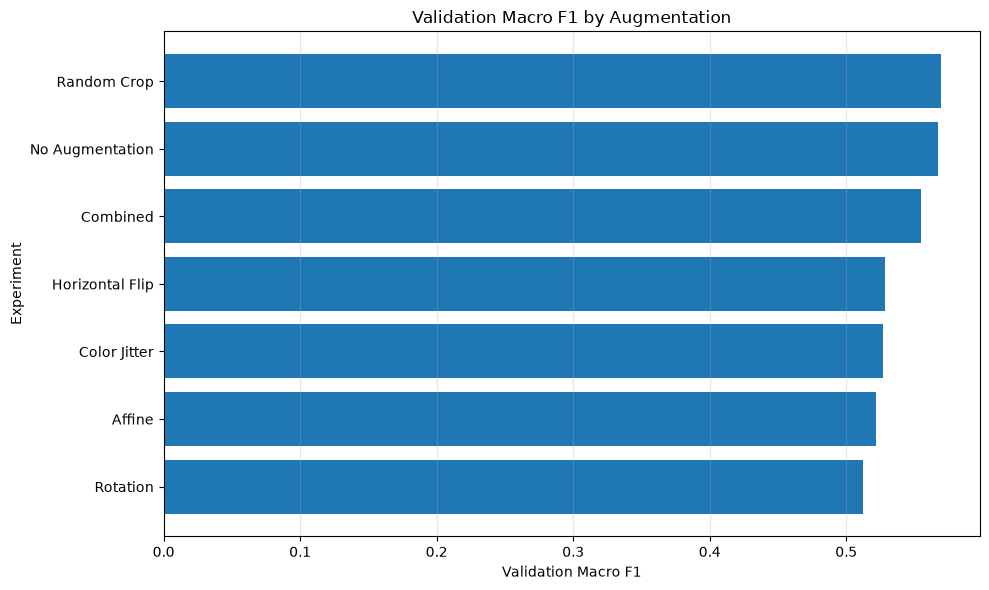

In [38]:
macro_f1_plot_df = plot_df.sort_values(
    "validation_macro_f1",
    ascending=True,
)

plt.figure(
    figsize=(10, 6)
)

plt.barh(
    macro_f1_plot_df["display_name"],
    macro_f1_plot_df["validation_macro_f1"],
)

plt.xlabel("Validation Macro F1")
plt.ylabel("Experiment")
plt.title(
    "Validation Macro F1 by Augmentation"
)

plt.grid(
    axis="x",
    alpha=0.3,
)

plt.tight_layout()

validation_f1_path = (
    FIGURES_DIR
    / "validation_macro_f1_comparison.png"
)

plt.savefig(
    validation_f1_path,
    dpi=300,
    bbox_inches="tight",
)

plt.show()

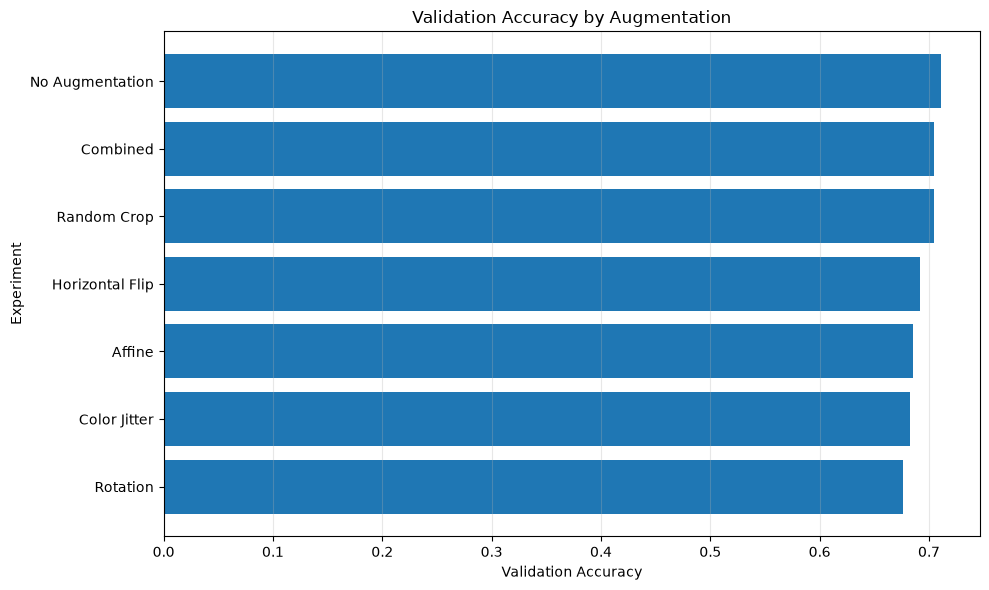

In [39]:
accuracy_plot_df = plot_df.sort_values(
    "validation_accuracy",
    ascending=True,
)

plt.figure(
    figsize=(10, 6)
)

plt.barh(
    accuracy_plot_df["display_name"],
    accuracy_plot_df["validation_accuracy"],
)

plt.xlabel("Validation Accuracy")
plt.ylabel("Experiment")
plt.title(
    "Validation Accuracy by Augmentation"
)

plt.grid(
    axis="x",
    alpha=0.3,
)

plt.tight_layout()

validation_accuracy_path = (
    FIGURES_DIR
    / "validation_accuracy_comparison.png"
)

plt.savefig(
    validation_accuracy_path,
    dpi=300,
    bbox_inches="tight",
)

plt.show()

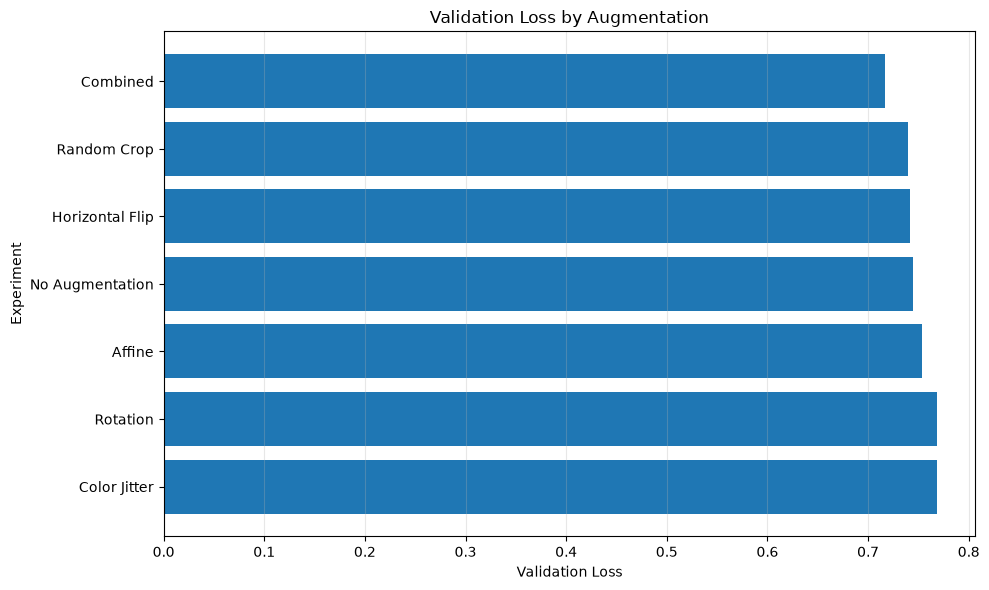

In [40]:
loss_plot_df = plot_df.sort_values(
    "validation_loss",
    ascending=False,
)

plt.figure(
    figsize=(10, 6)
)

plt.barh(
    loss_plot_df["display_name"],
    loss_plot_df["validation_loss"],
)

plt.xlabel("Validation Loss")
plt.ylabel("Experiment")
plt.title(
    "Validation Loss by Augmentation"
)

plt.grid(
    axis="x",
    alpha=0.3,
)

plt.tight_layout()

validation_loss_path = (
    FIGURES_DIR
    / "validation_loss_comparison.png"
)

plt.savefig(
    validation_loss_path,
    dpi=300,
    bbox_inches="tight",
)

plt.show()

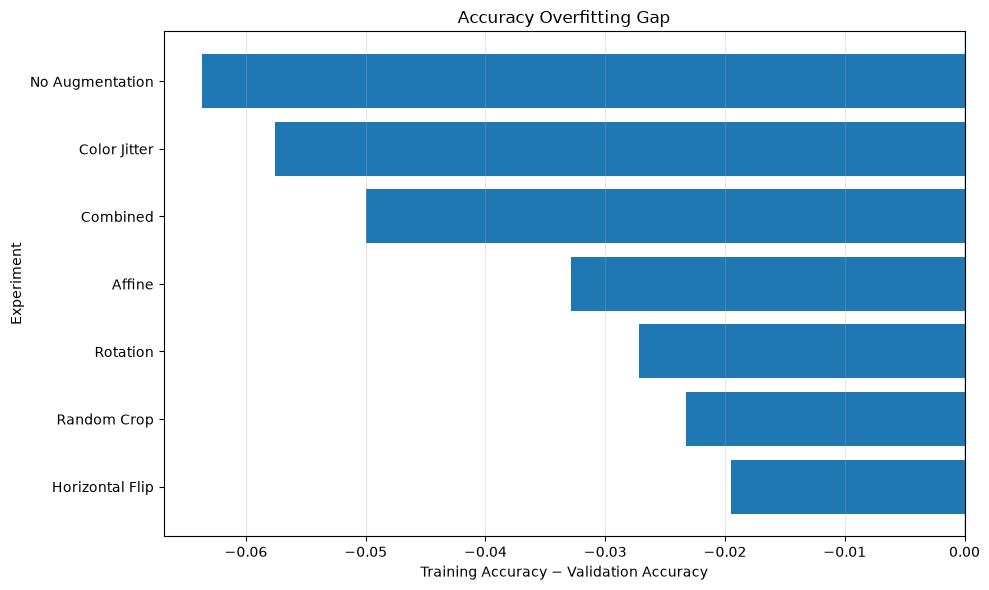

In [41]:
gap_plot_df = plot_df.sort_values(
    "accuracy_overfitting_gap",
    ascending=False,
)

plt.figure(
    figsize=(10, 6)
)

plt.barh(
    gap_plot_df["display_name"],
    gap_plot_df[
        "accuracy_overfitting_gap"
    ],
)

plt.axvline(
    x=0,
    linewidth=1,
)

plt.xlabel(
    "Training Accuracy − Validation Accuracy"
)

plt.ylabel("Experiment")

plt.title(
    "Accuracy Overfitting Gap"
)

plt.grid(
    axis="x",
    alpha=0.3,
)

plt.tight_layout()

overfitting_gap_path = (
    FIGURES_DIR
    / "overfitting_gap_comparison.png"
)

plt.savefig(
    overfitting_gap_path,
    dpi=300,
    bbox_inches="tight",
)

plt.show()

In [42]:
experiment_history_paths = {
    "no_augmentation": BASELINE_HISTORY_PATH,
    "horizontal_flip": (
        HISTORIES_DIR
        / "horizontal_flip_history.csv"
    ),
    "rotation": (
        HISTORIES_DIR
        / "rotation_history.csv"
    ),
    "random_crop": (
        HISTORIES_DIR
        / "random_crop_history.csv"
    ),
    "color_jitter": (
        HISTORIES_DIR
        / "color_jitter_history.csv"
    ),
    "affine": (
        HISTORIES_DIR
        / "affine_history.csv"
    ),
    "combined": (
        HISTORIES_DIR
        / "combined_history.csv"
    ),
}

experiment_histories = {}

for experiment_name, history_path in (
    experiment_history_paths.items()
):
    assert history_path.exists(), (
        f"Missing history: {history_path}"
    )

    experiment_histories[
        experiment_name
    ] = pd.read_csv(
        history_path
    )

print(
    f"Loaded {len(experiment_histories)} "
    "experiment histories."
)

Loaded 7 experiment histories.


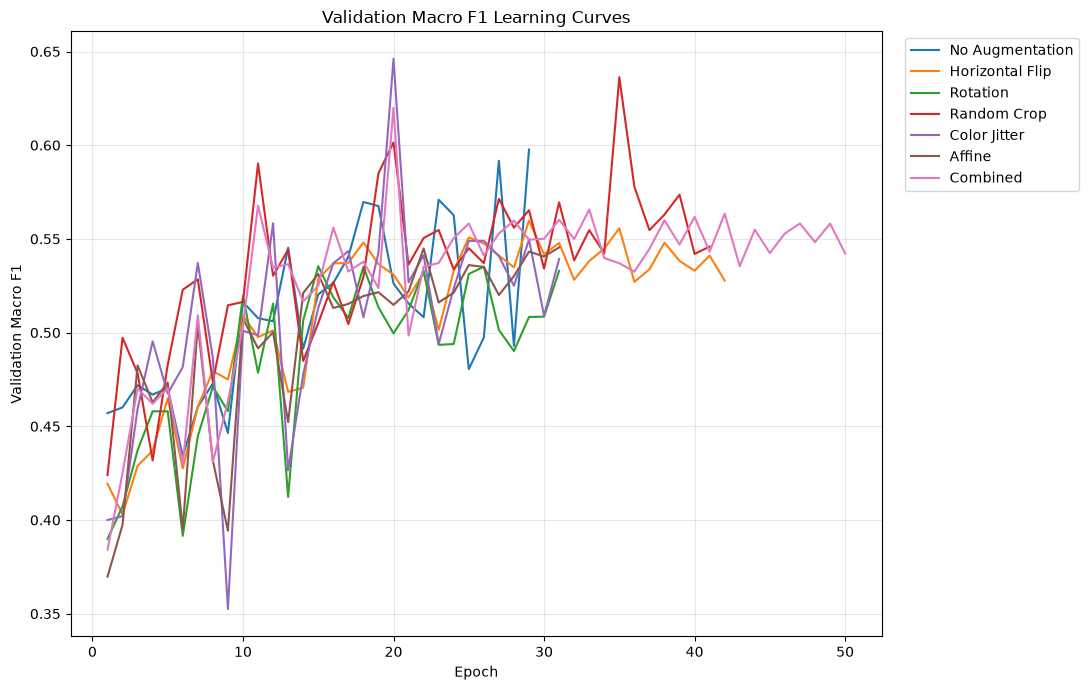

In [43]:
plt.figure(
    figsize=(11, 7)
)

for experiment_name, history_df in (
    experiment_histories.items()
):
    epochs = np.arange(
        1,
        len(history_df) + 1,
    )

    plt.plot(
        epochs,
        history_df["val_macro_f1"],
        label=experiment_display_names[
            experiment_name
        ],
    )

plt.xlabel("Epoch")
plt.ylabel("Validation Macro F1")
plt.title(
    "Validation Macro F1 Learning Curves"
)

plt.legend(
    bbox_to_anchor=(1.02, 1),
    loc="upper left",
)

plt.grid(
    alpha=0.3,
)

plt.tight_layout()

all_f1_curves_path = (
    FIGURES_DIR
    / "all_validation_f1_curves.png"
)

plt.savefig(
    all_f1_curves_path,
    dpi=300,
    bbox_inches="tight",
)

plt.show()

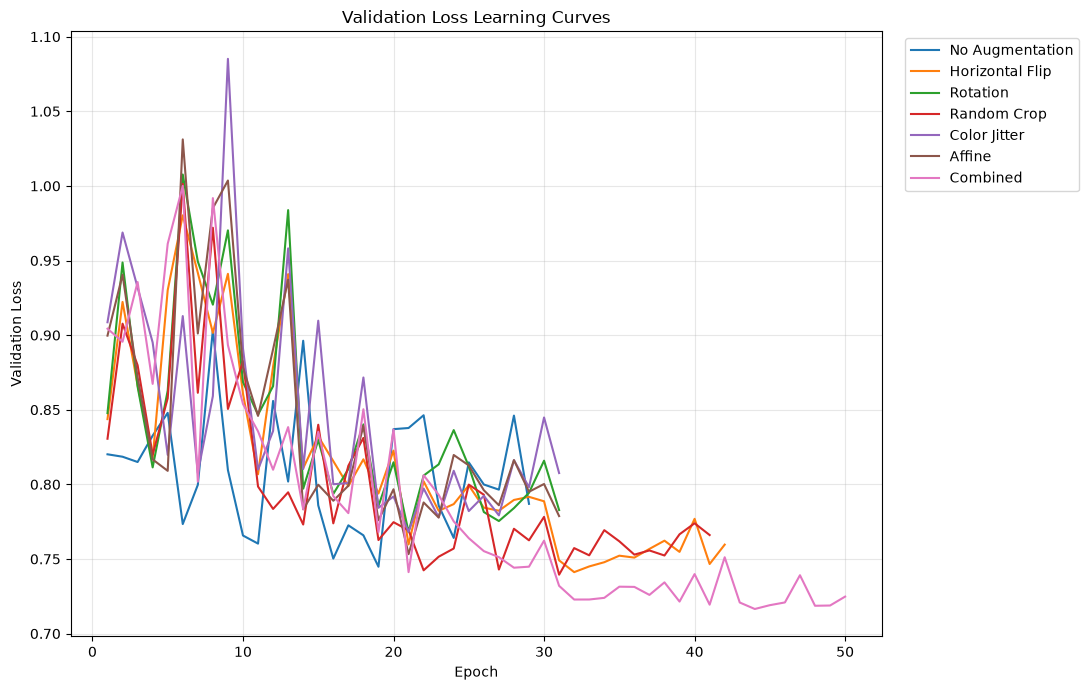

In [56]:
plt.figure(
    figsize=(11, 7)
)

for experiment_name, history_df in (
    experiment_histories.items()
):
    epochs = np.arange(
        1,
        len(history_df) + 1,
    )

    plt.plot(
        epochs,
        history_df["val_loss"],
        label=experiment_display_names[
            experiment_name
        ],
    )

plt.xlabel("Epoch")
plt.ylabel("Validation Loss")
plt.title(
    "Validation Loss Learning Curves"
)

plt.legend(
    bbox_to_anchor=(1.02, 1),
    loc="upper left",
)

plt.grid(
    alpha=0.3,
)

plt.tight_layout()

all_loss_curves_path = (
    FIGURES_DIR
    / "all_validation_loss_curves.png"
)

plt.savefig(
    all_loss_curves_path,
    dpi=300,
    bbox_inches="tight",
)

plt.show()

In [67]:
augmented_results_df = summary_df[
    summary_df["experiment"]
    != "no_augmentation"
].copy()

augmented_results_df = (
    augmented_results_df.sort_values(
        by=[
            "validation_macro_f1",
            "validation_loss",
            "accuracy_overfitting_gap",
        ],
        ascending=[
            False,
            True,
            True,
        ],
    )
    .reset_index(
        drop=True
    )
)

best_augmented_row = (
    augmented_results_df.iloc[0]
)

best_augmentation_name = str(
    best_augmented_row["experiment"]
)

best_augmentation_checkpoint = Path(
    best_augmented_row["checkpoint_path"]
)

best_augmentation_history = Path(
    best_augmented_row["history_path"]
)

print(
    "Best augmentation:"
    f" {best_augmentation_name}"
)

print(
    "Validation macro F1:"
    f" {best_augmented_row['validation_macro_f1']:.4f}"
)

print(
    "Validation accuracy:"
    f" {best_augmented_row['validation_accuracy']:.4f}"
)

print(
    "Validation loss:"
    f" {best_augmented_row['validation_loss']:.4f}"
)

print(
    "Accuracy overfitting gap:"
    f" {best_augmented_row['accuracy_overfitting_gap']:.4f}"
)

print(
    f"Checkpoint: {best_augmentation_checkpoint}"
)

Best augmentation: random_crop
Validation macro F1: 0.5695
Validation accuracy: 0.7048
Validation loss: 0.7395
Accuracy overfitting gap: -0.0232
Checkpoint: /home/uteam6/computer-vision-equine-grimace-scale/results/augmentation_experiments/checkpoints/random_crop_best.pth


In [77]:
baseline_comparison_row = summary_df[
    summary_df["experiment"]
    == "no_augmentation"
].iloc[0]

macro_f1_change = (
    best_augmented_row[
        "validation_macro_f1"
    ]
    - baseline_comparison_row[
        "validation_macro_f1"
    ]
)

accuracy_change = (
    best_augmented_row[
        "validation_accuracy"
    ]
    - baseline_comparison_row[
        "validation_accuracy"
    ]
)

validation_loss_change = (
    best_augmented_row[
        "validation_loss"
    ]
    - baseline_comparison_row[
        "validation_loss"
    ]
)

overfitting_gap_change = (
    best_augmented_row[
        "accuracy_overfitting_gap"
    ]
    - baseline_comparison_row[
        "accuracy_overfitting_gap"
    ]
)

comparison_df = pd.DataFrame(
    {
        "metric": [
            "Validation Macro F1",
            "Validation Accuracy",
            "Validation Loss",
            "Accuracy Overfitting Gap",
        ],
        "baseline": [
            baseline_comparison_row[
                "validation_macro_f1"
            ],
            baseline_comparison_row[
                "validation_accuracy"
            ],
            baseline_comparison_row[
                "validation_loss"
            ],
            baseline_comparison_row[
                "accuracy_overfitting_gap"
            ],
        ],
        "best_augmentation": [
            best_augmented_row[
                "validation_macro_f1"
            ],
            best_augmented_row[
                "validation_accuracy"
            ],
            best_augmented_row[
                "validation_loss"
            ],
            best_augmented_row[
                "accuracy_overfitting_gap"
            ],
        ],
        "change": [
            macro_f1_change,
            accuracy_change,
            validation_loss_change,
            overfitting_gap_change,
        ],
    }
)

comparison_path = (
    RESULTS_DIR
    / "baseline_vs_best_augmentation.csv"
)

comparison_df.to_csv(
    comparison_path,
    index=False,
)

display(comparison_df)

,metric,baseline,best_augmentation,change
0,Validation Macro F1,0.567535,0.569503,0.001968
1,Validation Accuracy,0.711111,0.704762,-0.006349
2,Validation Loss,0.744805,0.739484,-0.005321
3,Accuracy Overfitting Gap,-0.063688,-0.023243,0.040445


In [78]:
BEST_AUGMENTED_MODEL_PATH = (
    RESULTS_DIR
    / "best_augmented_model.pth"
)

BEST_AUGMENTED_HISTORY_PATH = (
    RESULTS_DIR
    / "best_augmented_history.csv"
)

shutil.copy2(
    best_augmentation_checkpoint,
    BEST_AUGMENTED_MODEL_PATH,
)

shutil.copy2(
    best_augmentation_history,
    BEST_AUGMENTED_HISTORY_PATH,
)

print(
    "Best augmented checkpoint copied to:"
)

print(BEST_AUGMENTED_MODEL_PATH)

print(
    "\nBest augmented history copied to:"
)

print(BEST_AUGMENTED_HISTORY_PATH)

Best augmented checkpoint copied to:
/home/uteam6/computer-vision-equine-grimace-scale/results/augmentation_experiments/best_augmented_model.pth

Best augmented history copied to:
/home/uteam6/computer-vision-equine-grimace-scale/results/augmentation_experiments/best_augmented_history.csv


In [79]:
best_augmentation_metadata = {
    "selected_experiment": (
        best_augmentation_name
    ),
    "selection_metric": (
        "validation_macro_f1"
    ),
    "validation_macro_f1": float(
        best_augmented_row[
            "validation_macro_f1"
        ]
    ),
    "validation_accuracy": float(
        best_augmented_row[
            "validation_accuracy"
        ]
    ),
    "validation_loss": float(
        best_augmented_row[
            "validation_loss"
        ]
    ),
    "accuracy_overfitting_gap": float(
        best_augmented_row[
            "accuracy_overfitting_gap"
    ]
),
    "baseline_validation_macro_f1": float(
        baseline_comparison_row[
            "validation_macro_f1"
        ]
    ),
    "macro_f1_change_from_baseline": float(
        macro_f1_change
    ),
    "accuracy_change_from_baseline": float(
        accuracy_change
    ),
    "validation_loss_change_from_baseline": float(
        validation_loss_change
    ),
    "accuracy_overfitting_gap_change_from_baseline": float(
        overfitting_gap_change
    ),
    "original_checkpoint_path": str(
        best_augmentation_checkpoint
    ),
    "canonical_checkpoint_path": str(
        BEST_AUGMENTED_MODEL_PATH
    ),
    "canonical_history_path": str(
        BEST_AUGMENTED_HISTORY_PATH
    ),
    "random_seed": SEED,
    "batch_size": BATCH_SIZE,
    "maximum_epochs": NUM_EPOCHS,
    "learning_rate": LEARNING_RATE,
    "weight_decay": WEIGHT_DECAY,
    "dropout_rate": DROPOUT_RATE,
}

best_augmentation_metadata_path = (
    RESULTS_DIR
    / "best_augmentation.json"
)

with open(
    best_augmentation_metadata_path,
    "w",
    encoding="utf-8",
) as output_file:
    json.dump(
        best_augmentation_metadata,
        output_file,
        indent=4,
    )

print(
    "Best-augmentation metadata saved to:"
)

print(best_augmentation_metadata_path)

Best-augmentation metadata saved to:
/home/uteam6/computer-vision-equine-grimace-scale/results/augmentation_experiments/best_augmentation.json


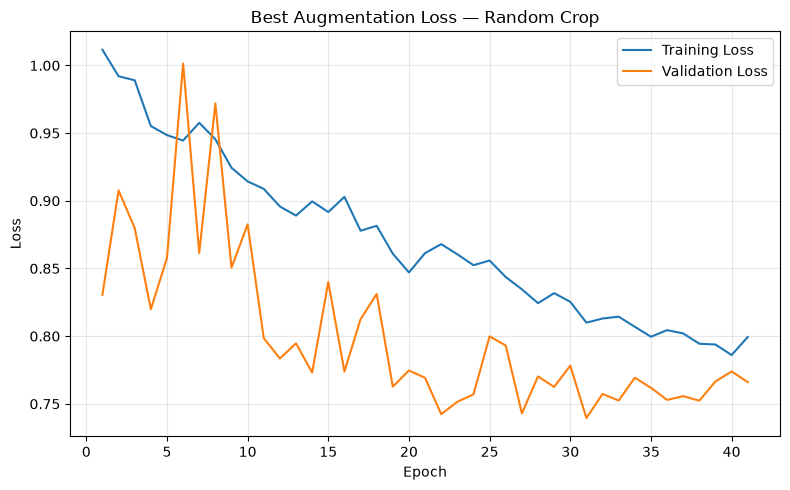

In [80]:
best_history_df = pd.read_csv(
    BEST_AUGMENTED_HISTORY_PATH
)

best_epochs = np.arange(
    1,
    len(best_history_df) + 1,
)

plt.figure(
    figsize=(8, 5)
)

plt.plot(
    best_epochs,
    best_history_df["train_loss"],
    label="Training Loss",
)

plt.plot(
    best_epochs,
    best_history_df["val_loss"],
    label="Validation Loss",
)

plt.xlabel("Epoch")
plt.ylabel("Loss")

plt.title(
    f"Best Augmentation Loss — "
    f"{experiment_display_names[best_augmentation_name]}"
)

plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()

best_loss_curve_path = (
    FIGURES_DIR
    / "best_augmentation_loss_curve.png"
)

plt.savefig(
    best_loss_curve_path,
    dpi=300,
    bbox_inches="tight",
)

plt.show()

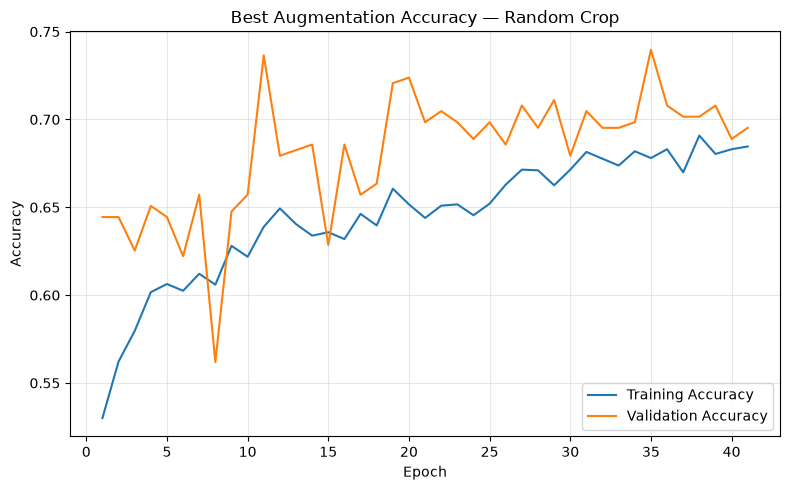

In [81]:
plt.figure(
    figsize=(8, 5)
)

plt.plot(
    best_epochs,
    best_history_df["train_accuracy"],
    label="Training Accuracy",
)

plt.plot(
    best_epochs,
    best_history_df["val_accuracy"],
    label="Validation Accuracy",
)

plt.xlabel("Epoch")
plt.ylabel("Accuracy")

plt.title(
    f"Best Augmentation Accuracy — "
    f"{experiment_display_names[best_augmentation_name]}"
)

plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()

best_accuracy_curve_path = (
    FIGURES_DIR
    / "best_augmentation_accuracy_curve.png"
)

plt.savefig(
    best_accuracy_curve_path,
    dpi=300,
    bbox_inches="tight",
)

plt.show()

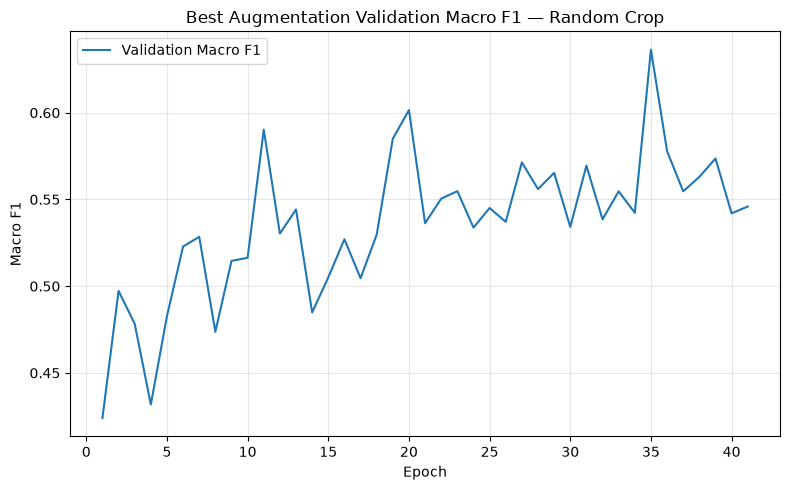

In [82]:
plt.figure(
    figsize=(8, 5)
)

plt.plot(
    best_epochs,
    best_history_df["val_macro_f1"],
    label="Validation Macro F1",
)

plt.xlabel("Epoch")
plt.ylabel("Macro F1")

plt.title(
    f"Best Augmentation Validation Macro F1 — "
    f"{experiment_display_names[best_augmentation_name]}"
)

plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()

best_f1_curve_path = (
    FIGURES_DIR
    / "best_augmentation_f1_curve.png"
)

plt.savefig(
    best_f1_curve_path,
    dpi=300,
    bbox_inches="tight",
)

plt.show()

In [83]:
if macro_f1_change > 0:
    macro_f1_statement = (
        f"The best augmentation increased validation "
        f"macro F1 by {macro_f1_change:.4f}."
    )
elif macro_f1_change < 0:
    macro_f1_statement = (
        f"The best augmentation decreased validation "
        f"macro F1 by {abs(macro_f1_change):.4f}."
    )
else:
    macro_f1_statement = (
        "The best augmentation produced the same "
        "validation macro F1 as the baseline."
    )

if overfitting_gap_change < 0:
    overfitting_statement = (
        f"It reduced the accuracy overfitting gap by "
        f"{abs(overfitting_gap_change):.4f}."
    )
elif overfitting_gap_change > 0:
    overfitting_statement = (
        f"It increased the accuracy overfitting gap by "
        f"{overfitting_gap_change:.4f}."
    )
else:
    overfitting_statement = (
        "It produced the same accuracy overfitting gap "
        "as the baseline."
    )

conclusion_text = (
    f"The best augmentation configuration was "
    f"'{experiment_display_names[best_augmentation_name]}'. "
    f"It achieved a validation macro F1 of "
    f"{best_augmented_row['validation_macro_f1']:.4f}, "
    f"a validation accuracy of "
    f"{best_augmented_row['validation_accuracy']:.4f}, "
    f"and a validation loss of "
    f"{best_augmented_row['validation_loss']:.4f}. "
    f"{macro_f1_statement} "
    f"{overfitting_statement}"
)

print(conclusion_text)

conclusion_path = (
    RESULTS_DIR
    / "phase4_conclusion.txt"
)

with open(
    conclusion_path,
    "w",
    encoding="utf-8",
) as output_file:
    output_file.write(
        conclusion_text
    )

print(
    f"\nConclusion saved to: "
    f"{conclusion_path}"
)

The best augmentation configuration was 'Random Crop'. It achieved a validation macro F1 of 0.5695, a validation accuracy of 0.7048, and a validation loss of 0.7395. The best augmentation increased validation macro F1 by 0.0020. It increased the accuracy overfitting gap by 0.0404.

Conclusion saved to: /home/uteam6/computer-vision-equine-grimace-scale/results/augmentation_experiments/phase4_conclusion.txt


In [85]:
print("=" * 80)
print("PHASE 4 COMPLETE")
print("=" * 80)

print(
    f"Best augmentation: "
    f"{experiment_display_names[best_augmentation_name]}"
)

print(
    f"Validation macro F1: "
    f"{best_augmented_row['validation_macro_f1']:.4f}"
)

print(
    f"Validation accuracy: "
    f"{best_augmented_row['validation_accuracy']:.4f}"
)

print(
    f"Validation loss: "
    f"{best_augmented_row['validation_loss']:.4f}"
)

print(
    f"Accuracy overfitting gap: "
    f"{best_augmented_row['accuracy_overfitting_gap']:.4f}"
)

print(
    f"Macro-F1 change from baseline: "
    f"{macro_f1_change:+.4f}"
)

print(
    f"\nBest checkpoint: "
    f"{BEST_AUGMENTED_MODEL_PATH}"
)

print(
    f"Experiment summary: "
    f"{summary_path}"
)

print(
    f"Metadata: "
    f"{best_augmentation_metadata_path}"
)

PHASE 4 COMPLETE
Best augmentation: Random Crop
Validation macro F1: 0.5695
Validation accuracy: 0.7048
Validation loss: 0.7395
Accuracy overfitting gap: -0.0232
Macro-F1 change from baseline: +0.0020

Best checkpoint: /home/uteam6/computer-vision-equine-grimace-scale/results/augmentation_experiments/best_augmented_model.pth
Experiment summary: /home/uteam6/computer-vision-equine-grimace-scale/results/augmentation_experiments/experiment_summary.csv
Metadata: /home/uteam6/computer-vision-equine-grimace-scale/results/augmentation_experiments/best_augmentation.json


In [86]:
expected_files = [
    RESULTS_DIR / "experiment_summary.csv",
    RESULTS_DIR / "baseline_vs_best_augmentation.csv",
    RESULTS_DIR / "best_augmented_model.pth",
    RESULTS_DIR / "best_augmented_history.csv",
    RESULTS_DIR / "best_augmentation.json",
    RESULTS_DIR / "phase4_conclusion.txt",

    FIGURES_DIR / "augmentation_samples.png",
    FIGURES_DIR / "combined_augmentation_samples.png",
    FIGURES_DIR / "validation_macro_f1_comparison.png",
    FIGURES_DIR / "validation_accuracy_comparison.png",
    FIGURES_DIR / "validation_loss_comparison.png",
    FIGURES_DIR / "overfitting_gap_comparison.png",
    FIGURES_DIR / "all_validation_f1_curves.png",
    FIGURES_DIR / "all_validation_loss_curves.png",
    FIGURES_DIR / "best_augmentation_loss_curve.png",
    FIGURES_DIR / "best_augmentation_accuracy_curve.png",
    FIGURES_DIR / "best_augmentation_f1_curve.png",
]

for experiment_name in augmentation_transforms:
    expected_files.extend(
        [
            CHECKPOINTS_DIR
            / f"{experiment_name}_best.pth",

            HISTORIES_DIR
            / f"{experiment_name}_history.csv",

            RESULTS_DIR
            / (
                f"{experiment_name}"
                "_validation_metrics.json"
            ),
        ]
    )

for file_path in expected_files:
    status = (
        "FOUND"
        if file_path.exists()
        else "MISSING"
    )

    print(
        f"{file_path.name:<45} "
        f"{status}"
    )

experiment_summary.csv                        FOUND
baseline_vs_best_augmentation.csv             FOUND
best_augmented_model.pth                      FOUND
best_augmented_history.csv                    FOUND
best_augmentation.json                        FOUND
phase4_conclusion.txt                         FOUND
augmentation_samples.png                      FOUND
combined_augmentation_samples.png             FOUND
validation_macro_f1_comparison.png            FOUND
validation_accuracy_comparison.png            FOUND
validation_loss_comparison.png                FOUND
overfitting_gap_comparison.png                FOUND
all_validation_f1_curves.png                  FOUND
all_validation_loss_curves.png                FOUND
best_augmentation_loss_curve.png              FOUND
best_augmentation_accuracy_curve.png          FOUND
best_augmentation_f1_curve.png                FOUND
horizontal_flip_best.pth                      FOUND
horizontal_flip_history.csv                   FOUND
horizontal_f